# Combined Analysis: POSTC-Requested × POSTC × DESE

**Goal:** Use POSTC-Requested (PRR-based complaint data) as the anchor and connect it to:  
- **POSTC_ComplaintsRawData** — structured complaint/allegation records from the POST Commission  
- **DESE Student Discipline** — MA school district discipline rates (2020-21 through 2024-25)  

**Link strategy:**  
- POSTC-Requested ↔ POSTC: `REPORTINGAGENCY` (agency name, exact match — 94 agencies overlap)  
- POSTC-Requested+POSTC ↔ DESE: extract city from agency name → match `District Name`  

**Key question:** In jurisdictions where POSTC-Requested shows officer misconduct complaints, do we see elevated SRO activity (POSTC) and higher school discipline rates (DESE)?

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.dpi'] = 120

DATA_DIR = '../data'

# ── Load POSTC-Requested ──────────────────────────────────────────────────────────────
dank = pd.read_csv(f'{DATA_DIR}/Dankoff_PRR_Merged.csv')
dank['CREATEDDATE'] = pd.to_datetime(dank['CREATEDDATE'], errors='coerce')
dank['year'] = dank['CREATEDDATE'].dt.year

school_kw = r'school|student|juvenile|minor|youth|teen|\bsro\b|resource officer'
dank_text = (dank['NARRATIVE'].fillna('') + ' ' + dank['UPDATEDNARRATIVE'].fillna('')).str.lower()
dank['school_related'] = dank_text.str.contains(school_kw, regex=True)
dank['is_SRO'] = dank['CERTIFICATIONSTATUS'] == 'Certified/SRO'

bias_cols = ['bias', 'racial bias', 'ethnicity', 'gender identity',
             'sexual orientation', 'age', 'religion',
             'mental or physical disability', 'immigration status', 'socioeconomic level']
dank['bias_claimed'] = dank[bias_cols].notna().any(axis=1)

# ── Load POSTC ────────────────────────────────────────────────────────────────
postc = pd.read_csv(f'{DATA_DIR}/POSTC_ComplaintsRawData_20260203.csv')
postc['INCIDENT_DATE'] = pd.to_datetime(postc['INCIDENT_DATE'], errors='coerce')
postc['year'] = postc['INCIDENT_DATE'].dt.year

postc['is_SRO'] = postc['CERTIFICATION_STATUS'] == 'Certified/SRO'
postc_text = (postc['ALLEGATION_DETAILS'].fillna('') + ' ' + postc['COMPLAINT_SUMMARY'].fillna('')).str.lower()
postc['school_related'] = postc_text.str.contains(school_kw, regex=True)

# ── Load DESE ─────────────────────────────────────────────────────────────────
dese_files = {
    '2020-21': f'{DATA_DIR}/StudentDisciplineDataReport_2020_to_2021.xlsx',
    '2021-22': f'{DATA_DIR}/StudentDisciplineDataReport_2021_to_2022.xlsx',
    '2022-23': f'{DATA_DIR}/StudentDisciplineDataReport_2022_to_2023.xlsx',
    '2023-24': f'{DATA_DIR}/StudentDisciplineDataReport_2023_to_2024.xlsx',
    '2024-25': f'{DATA_DIR}/StudentDisciplineDataReport_2024_to_2025.xlsx',
}
frames = []
for yr, path in dese_files.items():
    df = pd.read_excel(path, skiprows=1)
    for col in df.columns[2:]:
        df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', '').str.strip(), errors='coerce')
    df['school_year'] = yr
    df['year_start'] = int(yr[:4])
    frames.append(df)
dese = pd.concat(frames, ignore_index=True)
dese = dese[dese['District Name'] != 'State Totals'].copy()
dese['Discipline Rate'] = dese['Students Disciplined'] / dese['Students'] * 100
dese['is_charter'] = dese['District Name'].str.contains('Charter|charter', na=False)

# ── City extraction helper ────────────────────────────────────────────────────
# Maps bare institution name → host city (checked before AND after suffix stripping)
AGENCY_CITY_MAP = {
    # Pioneer Valley / Western MA
    'Mount Holyoke College':                    'South Hadley',
    'Western New England University':           'Springfield',
    'Springfield College':                      'Springfield',
    'American International College':           'Springfield',
    'Springfield Technical Community College':  'Springfield',
    'Westfield State University':               'Westfield',
    'Holyoke Community College':                'Holyoke',
    'Smith College':                            'Northampton',
    # Greater Boston
    'Boston College':                           'Newton',
    'Boston University':                        'Boston',
    'Northeastern University':                  'Boston',
    'Harvard University':                       'Cambridge',
    'Tufts University':                         'Medford',
    'Brandeis University':                      'Waltham',
    'Bentley University':                       'Waltham',
    'Babson College':                           'Wellesley',
    'Wellesley College':                        'Wellesley',
    'Lasell University':                        'Newton',
    'Emerson College':                          'Boston',
    'Berklee College of Music':                 'Boston',
    'Simmons University':                       'Boston',
    'Suffolk University':                       'Boston',
    'Massachusetts College of Art':             'Boston',
    'Massachusetts College of Pharmacy and Health Sciences': 'Boston',
    # Metro North / South Shore
    'Bridgewater State University':             'Bridgewater',
    'Massasoit Community College':              'Brockton',
    'Stonehill College':                        'Easton',
    'Endicott College':                         'Beverly',
    'Salem State University':                   'Salem',
    'North Shore Community College':            'Danvers',
    'Northern Essex Community College':         'Haverhill',
    'Merrimack College':                        'North Andover',
    # Central MA
    'Clark University':                         'Worcester',
    'College of the Holy Cross':                'Worcester',
    'Assumption University':                    'Worcester',
    'Worcester State University':               'Worcester',
    'Quinsigamond Community College':           'Worcester',
    'Mount Wachusett Community College':        'Gardner',
    'Fitchburg State University':               'Fitchburg',
    'Framingham State University':              'Framingham',
    'Anna Maria College':                       'Paxton',
    'Massachusetts College of Liberal Arts':    'North Adams',
    'Amherst College':                          'Amherst',
    # UMass system (full names used in POSTC data)
    'University of Massachusetts at Amherst':   'Amherst',
    'University of Massachusetts at Boston':    'Boston',
    'University of Massachusetts at Dartmouth': 'Dartmouth',
    'University of Massachusetts at Lowell':    'Lowell',
    'UMass Amherst':                            'Amherst',
    'UMass Boston':                             'Boston',
    'UMass Dartmouth':                          'Dartmouth',
    'UMass Lowell':                             'Lowell',
    # Community colleges
    'Bristol Community College':                'Fall River',
    'Cape Cod Community College':               'Barnstable',
    'Middlesex Community College':              'Lowell',
    'Massachusetts Bay Community College':      'Wellesley',
}

def extract_city(agency: str) -> str:
    """Strip department suffixes or map known non-municipal agencies to city.
    Checks AGENCY_CITY_MAP both before AND after suffix stripping so that
    e.g. 'Mount Holyoke College Police Department' → 'South Hadley'.
    Longer/more-specific suffixes are listed first to avoid partial matches.
    """
    if agency in AGENCY_CITY_MAP:
        return AGENCY_CITY_MAP[agency]
    suffixes = [
        ' Department of Public Safety',   # must come before ' Police'
        ' - Campus Police',               # must come before ' Police'
        ' Police Department',
        ' Police Dept',
        ' Police',
        ' Sheriff',
        "'s Office",
    ]
    for s in suffixes:
        if agency.endswith(s):
            stripped = agency[:-len(s)].strip()
            return AGENCY_CITY_MAP.get(stripped, stripped)
    return agency.strip()

dank['city'] = dank['REPORTINGAGENCY'].fillna('').apply(extract_city)
postc['city'] = postc['REPORTING_AGENCY'].fillna('').apply(extract_city)

# ── Summary ───────────────────────────────────────────────────────────────────
dank_sro_rows       = dank['is_SRO'].sum()
dank_sro_complaints = dank[dank['is_SRO']]['COMPLAINTNUMBER'].nunique()

print(f'POSTC-Requested: {len(dank)} rows | school-related rows: {dank["school_related"].sum()}')
print(f'         SRO rows: {dank_sro_rows} (= {dank_sro_complaints} unique complaints — one complaint may span multiple rows)')
print(f'POSTC:   {len(postc)} rows | school-related: {postc["school_related"].sum()} | SRO complaints: {postc["is_SRO"].sum()}')
print(f'DESE:    {len(dese)} rows | {dese["District Name"].nunique()} districts | {dese["school_year"].nunique()} years')

# ── Sanity check: verify university→city mapping ──────────────────────────────
uni_kw = r'college|university'
postc_uni = postc[postc['REPORTING_AGENCY'].str.contains(uni_kw, case=False, na=False)][['REPORTING_AGENCY','city']].drop_duplicates().sort_values('REPORTING_AGENCY')
print('\nUniversity agency → city mapping (POSTC):')
print(postc_uni.to_string(index=False))


POSTC-Requested: 378 rows | school-related rows: 186
         SRO rows: 24 (= 15 unique complaints — one complaint may span multiple rows)
POSTC:   8759 rows | school-related: 92 | SRO complaints: 153
DESE:    1993 rows | 417 districts | 5 years

University agency → city mapping (POSTC):
                                     REPORTING_AGENCY                                            city
                               Amherst College Police                                         Amherst
    Assumption University Department of Public Safety                                       Worcester
                                       Babson College                                       Wellesley
                     Babson College Police Department                                       Wellesley
                                   Bentley University                                         Waltham
                             Berklee College of Music                                          Bost

---
## 1. POSTC-Requested × POSTC — Agency-Level Overlap

Both datasets track officer complaints at Massachusetts police agencies.  
We join on `REPORTINGAGENCY` to find agencies that appear in **both** datasets, then flag school-related activity.

**School-related flagging method:**
- **SRO flag:** `CERTIFICATION_STATUS == 'Certified/SRO'` (POSTC) / `CERTIFICATIONSTATUS == 'Certified/SRO'` (POSTC-Requested)
- **Keyword flag (narrative text):** `school`, `student`, `juvenile`, `minor`, `youth`, `teen`, `sro`, `resource officer`
- A complaint counts as school-related if it matches **either** the SRO flag or any keyword

> **Note on skew:** Springfield dominates the raw count chart due to its size and complaint volume. The per-1,000-students chart on the right corrects for this — smaller agencies with fewer students but proportionally high complaint rates surface there.


Cities in both datasets: 86
Of those, with SRO/school in POSTC: 19


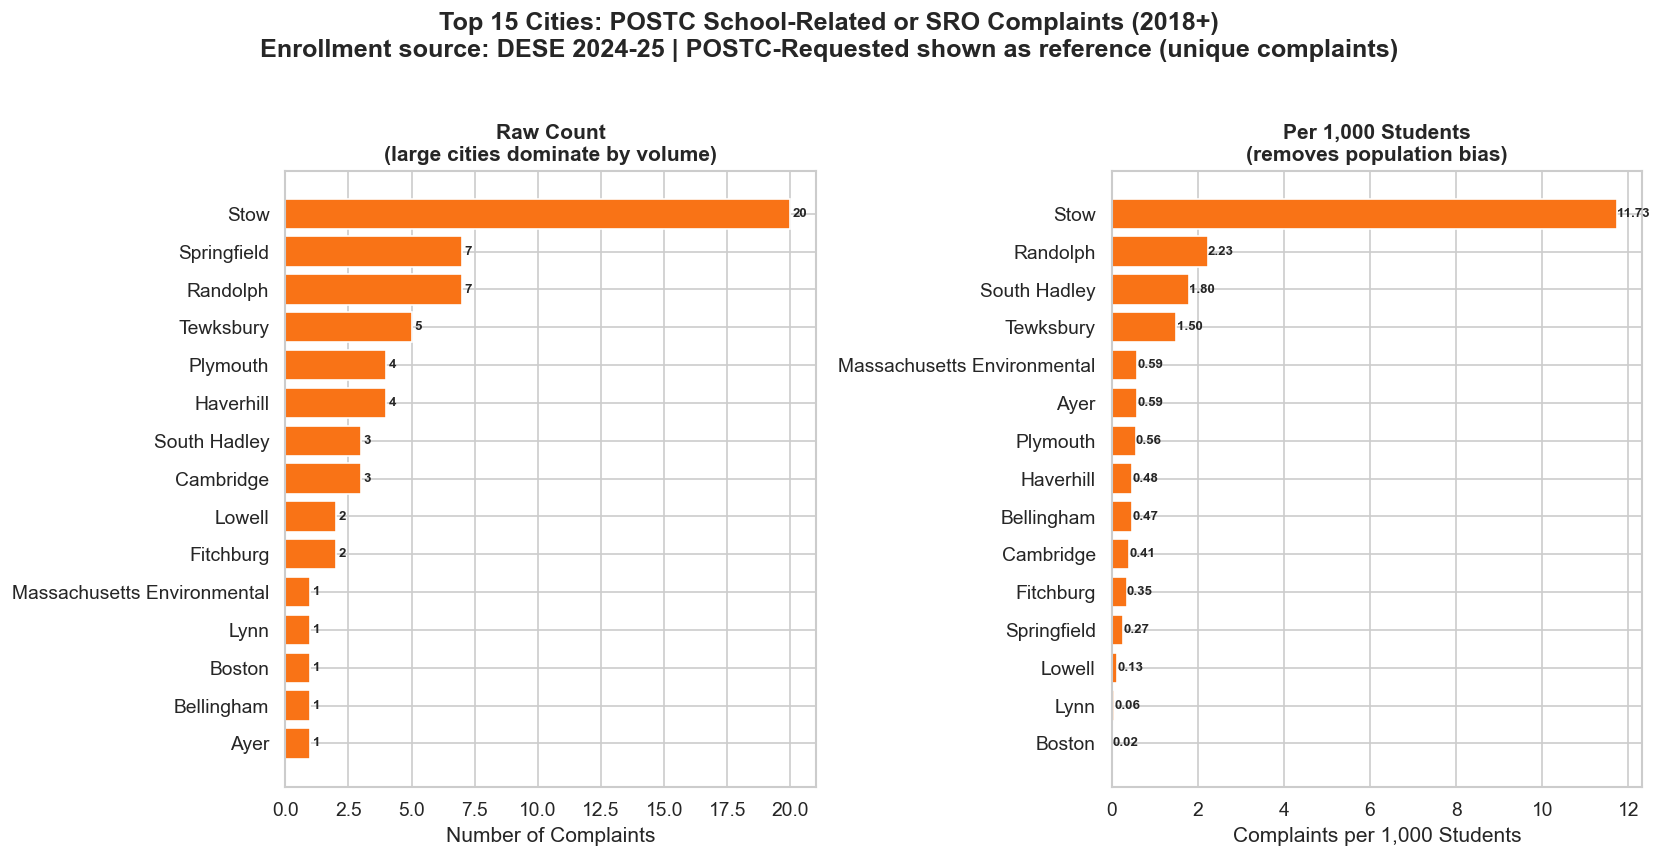

,City,POSTC Total (2018+),POSTC School/SRO,POSTC-Requested Unique Complaints (ref),POSTC-Requested School-Related (ref),Enrollment (est.)
0,Stow,22,20,1,1,1705.0
1,Randolph,62,7,2,1,3140.0
2,Springfield,307,7,3,2,25598.0
3,Tewksbury,34,5,1,1,3323.0
4,Haverhill,51,4,2,0,8369.0
5,Plymouth,69,4,4,2,7165.0
6,Cambridge,161,3,2,2,7380.0
7,South Hadley,4,3,1,1,1671.0
8,Fitchburg,40,2,1,1,5770.0
9,Lowell,70,2,7,3,15532.0


In [59]:
# Aggregate POSTC-Requested by agency (reference only — not shown in chart)
# Use nunique on COMPLAINTNUMBER to avoid double-counting multi-row complaints
dank_agg = dank.groupby('REPORTINGAGENCY').agg(
    dank_complaints = ('COMPLAINTNUMBER', 'nunique'),
    dank_sro        = ('is_SRO', 'sum'),
    dank_bias       = ('bias_claimed', 'sum'),
    dank_force      = ('Excessive Force', lambda x: x.notna().sum()),
).reset_index()

# dank_school: unique complaint numbers where school_related=True (not row count)
dank_school_agg = (
    dank[dank['school_related']]
    .groupby('REPORTINGAGENCY')['COMPLAINTNUMBER'].nunique()
    .reset_index(name='dank_school')
)
dank_agg = dank_agg.merge(dank_school_agg, on='REPORTINGAGENCY', how='left')
dank_agg['dank_school'] = dank_agg['dank_school'].fillna(0).astype(int)

# Aggregate POSTC by agency (2018+ by INCIDENT_DATE)
postc_2018 = postc[postc['year'] >= 2018]
postc_agg = postc_2018.groupby('REPORTING_AGENCY').agg(
    postc_complaints  = ('POST', 'count'),
    postc_school_sro  = ('POST', lambda x: postc_2018.loc[x.index, ['is_SRO', 'school_related']].any(axis=1).sum()),
    postc_sro         = ('is_SRO', 'sum'),
    postc_sustained   = ('LEA_DISPOSITION', lambda x: (x == 'Sustained').sum()),
).reset_index()

# Inner join — agencies in BOTH datasets
agency_join = dank_agg.merge(
    postc_agg, left_on='REPORTINGAGENCY', right_on='REPORTING_AGENCY', how='inner'
).drop(columns='REPORTING_AGENCY')
agency_join['city'] = agency_join['REPORTINGAGENCY'].apply(extract_city)

# ── Merge by city: multiple agencies in same city get combined ────────────────
city_join = agency_join.groupby('city').agg(
    postc_complaints  = ('postc_complaints', 'sum'),
    postc_school_sro  = ('postc_school_sro', 'sum'),
    dank_complaints   = ('dank_complaints', 'sum'),
    dank_school       = ('dank_school', 'sum'),
).reset_index()
city_join['school_score'] = city_join['postc_school_sro']

print(f'Cities in both datasets: {len(city_join)}')
print(f'Of those, with SRO/school in POSTC: {(city_join["postc_school_sro"] > 0).sum()}')

# Join DESE enrollment for normalization
dese_enroll = dese[(dese['school_year'] == '2024-25') & (~dese['is_charter'])][['District Name', 'Students']]
top_cities = city_join.nlargest(15, 'school_score').copy()
top_cities = top_cities.merge(dese_enroll, left_on='city', right_on='District Name', how='left').drop(columns='District Name')
enroll_median = dese_enroll['Students'].median()
top_cities['students'] = top_cities['Students'].fillna(enroll_median)

# ── Chart: Raw + per-1k ────────────────────────────────────────────────────────
top_raw   = top_cities.sort_values('school_score', ascending=True)
top_per1k = top_cities.copy()
top_per1k['sro_per1k'] = top_per1k['postc_school_sro'] / top_per1k['students'] * 1000
top_per1k = top_per1k.sort_values('sro_per1k', ascending=True)

C = '#f97316'
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

axes[0].barh(top_raw['city'], top_raw['postc_school_sro'], color=C)
for i, (_, row) in enumerate(top_raw.iterrows()):
    axes[0].text(row['postc_school_sro'] + 0.1, i, str(int(row['postc_school_sro'])),
                 va='center', fontsize=8, fontweight='bold')
axes[0].set_xlabel('Number of Complaints')
axes[0].set_title('Raw Count\n(large cities dominate by volume)', fontweight='bold')

axes[1].barh(top_per1k['city'], top_per1k['sro_per1k'], color=C)
for i, (_, row) in enumerate(top_per1k.iterrows()):
    axes[1].text(row['sro_per1k'] + 0.005, i, f"{row['sro_per1k']:.2f}",
                 va='center', fontsize=8, fontweight='bold')
axes[1].set_xlabel('Complaints per 1,000 Students')
axes[1].set_title('Per 1,000 Students\n(removes population bias)', fontweight='bold')

plt.suptitle('Top 15 Cities: POSTC School-Related or SRO Complaints (2018+)\n'
             'Enrollment source: DESE 2024-25 | POSTC-Requested shown as reference (unique complaints)',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Reference table
top_cities.sort_values('school_score', ascending=False)[
    ['city','postc_complaints','postc_school_sro','dank_complaints','dank_school','students']
].rename(columns={
    'city':             'City',
    'postc_complaints': 'POSTC Total (2018+)',
    'postc_school_sro': 'POSTC School/SRO',
    'dank_complaints':  'POSTC-Requested Unique Complaints (ref)',
    'dank_school':      'POSTC-Requested School-Related (ref)',
    'students':         'Enrollment (est.)'
}).round(0).reset_index(drop=True)


---
## 2. POSTC-Requested School-Related Cases — Deep Dive

~186 POSTC-Requested rows (49%) mention school/youth keywords in their narratives (keyword heuristic).  
Among those, some involve officers with `Certified/SRO` status — note that POSTC-Requested may have **multiple rows per complaint**, so row count ≠ unique complaint count.  
Here we look at what types of complaints these are and whether bias was claimed.

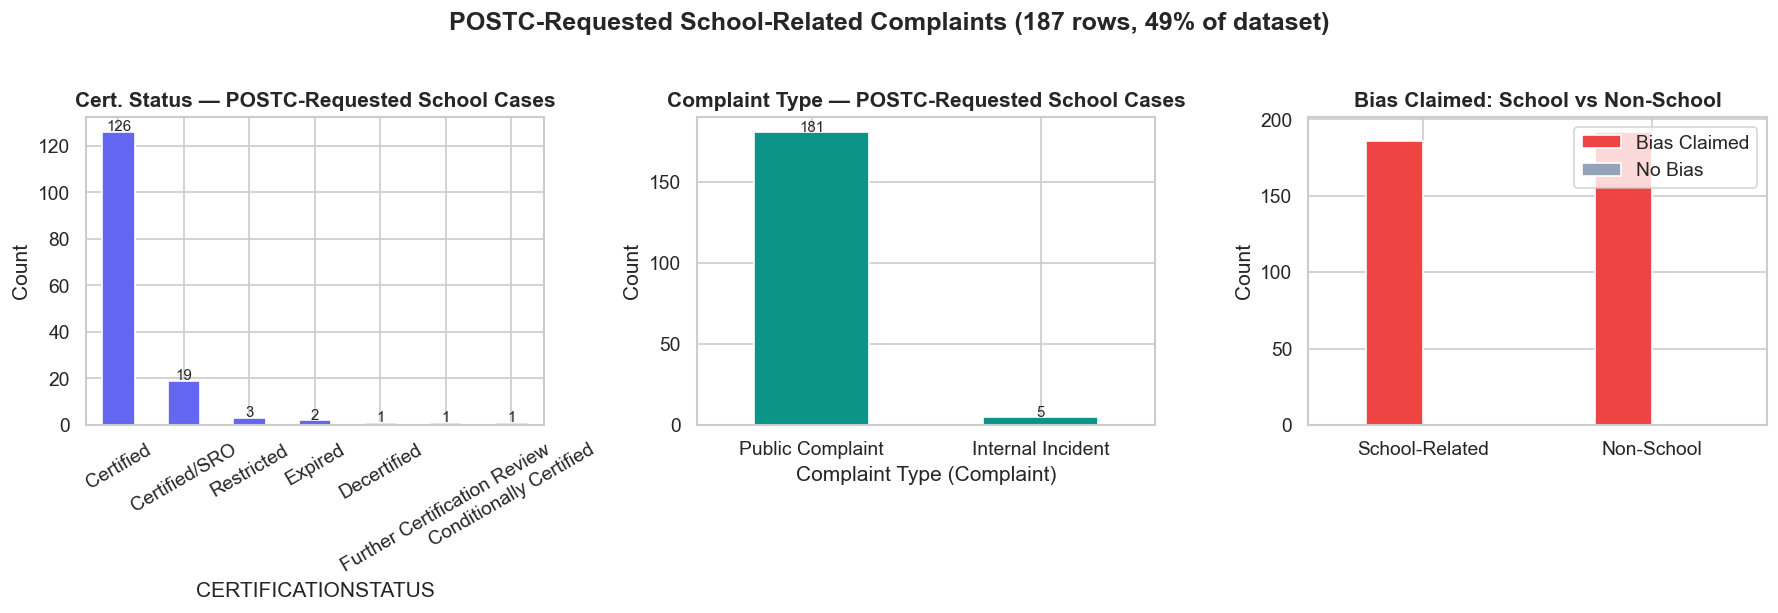

Sample POSTC-Requested school-related narratives:
  [nan | Certified/SRO]
  On the evening of October 29, 2022 my daughter attended a Halloween party.  She had no expectation that any drugs or alcohol would be present.  Members of the [REDACTED] school football team arrived w

  [nan | nan]
  Beginning in May of 2022 I began having to contact the Deerfield PD for ongoing civilian issues and disputes between my neighbor and myself. I disclosed during my first contact with officers from the 

  [nan | Certified]
  Had my land surveyed. Neighbor police officer for Chelmsford MA PD K9 officer did not like the survey results. Has been using his police status as a tool to empower and harrass me and my family. He po

  [Lowell Police Department | Certified]
  This is a Report Im attaching to be added to my report filed on DEC 4th through this portal. I called 2x on the 12th to Follow up and got no response. I just emailed an adress that it seems maybe was 

  [nan | Certified]
  This complain

In [60]:
dank_school = dank[dank['school_related']].copy()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Certification status of officers in school-related complaints
cert = dank_school['CERTIFICATIONSTATUS'].value_counts()
cert.plot.bar(ax=axes[0], color='#6366f1', rot=30)
axes[0].set_title('Cert. Status — POSTC-Requested School Cases', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(cert):
    axes[0].text(i, v + 0.3, str(v), ha='center', fontsize=9)

# Complaint type breakdown
ctype = dank_school['Complaint Type (Complaint)'].value_counts()
ctype.plot.bar(ax=axes[1], color='#0d9488', rot=0)
axes[1].set_title('Complaint Type — POSTC-Requested School Cases', fontweight='bold')
axes[1].set_ylabel('Count')
for i, v in enumerate(ctype):
    axes[1].text(i, v + 0.3, str(v), ha='center', fontsize=9)

# Bias claimed vs not, school vs non-school
bias_comp = pd.DataFrame({
    'School-Related':     [dank_school['bias_claimed'].sum(), (~dank_school['bias_claimed']).sum()],
    'Non-School':         [(dank[~dank['school_related']]['bias_claimed']).sum(),
                           (~dank[~dank['school_related']]['bias_claimed']).sum()],
}, index=['Bias Claimed', 'No Bias'])
bias_comp.T.plot.bar(ax=axes[2], color=['#ef4444', '#94a3b8'], rot=0)
axes[2].set_title('Bias Claimed: School vs Non-School', fontweight='bold')
axes[2].set_ylabel('Count')
axes[2].legend()

plt.suptitle('POSTC-Requested School-Related Complaints (187 rows, 49% of dataset)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Sample narratives
print('Sample POSTC-Requested school-related narratives:')
for i, row in dank_school[dank_school['NARRATIVE'].notna()].head(5).iterrows():
    print(f'  [{row["REPORTINGAGENCY"]} | {row["CERTIFICATIONSTATUS"]}]')
    print(f'  {str(row["NARRATIVE"])[:200]}')
    print()

---
## 3. Three-Way Join: POSTC-Requested × POSTC × DESE

We extract the **city name** from each agency and match it to DESE `District Name`.  
This lets us compare, for the same city:  
- **POSTC-Requested** complaints (incl. school-related & SRO)  
- **POSTC** SRO complaint count  
- **DESE** discipline rate and school-based arrest rate

Cities in all three datasets: 202
Cities with POSTC-Requested school-related > 0: 51
Cities with POSTC SRO complaints > 0:   38


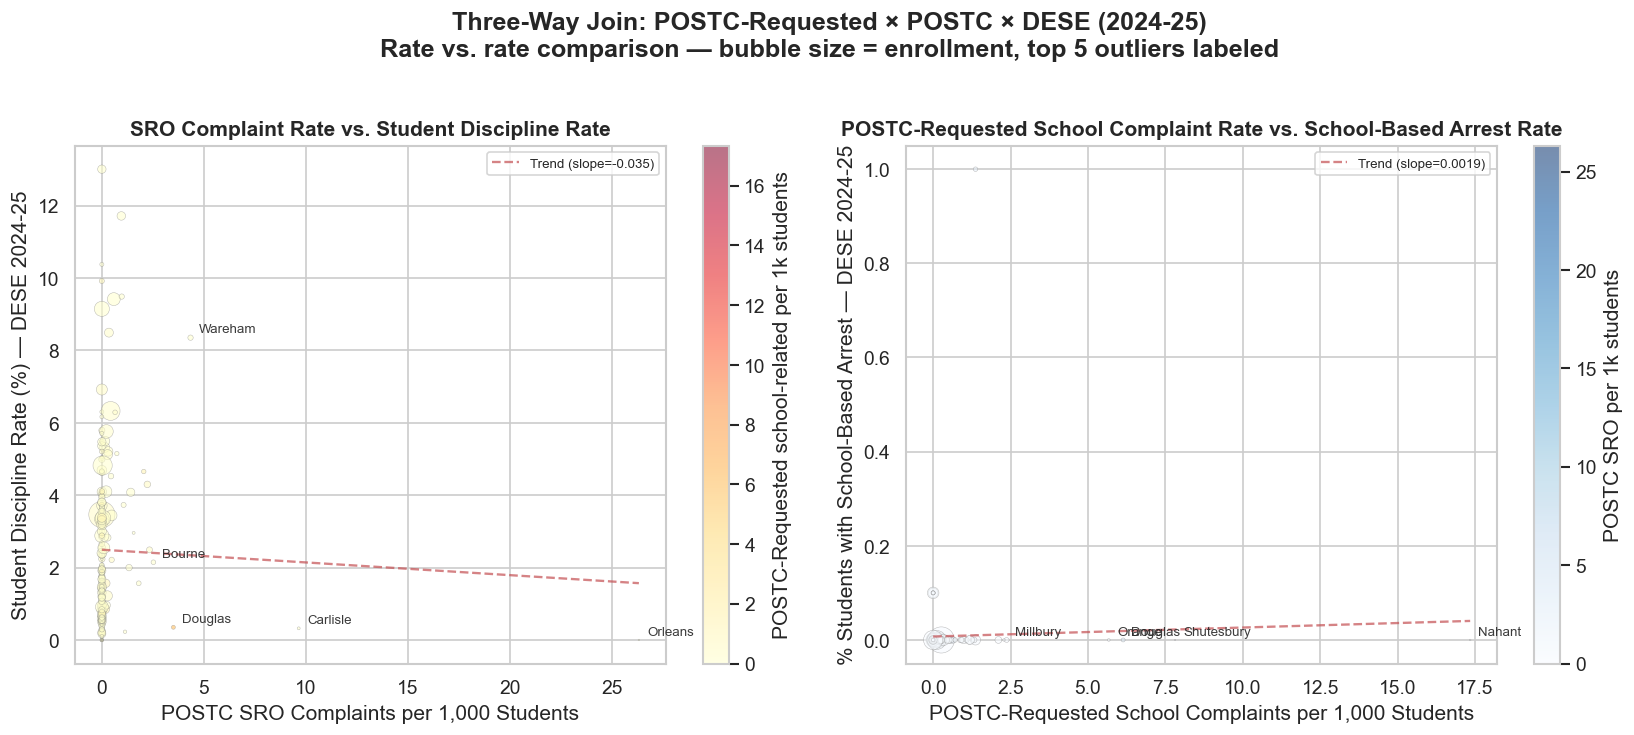

In [61]:
# DESE: aggregate to city level (latest year, traditional public only)
dese_latest = dese[(dese['school_year'] == '2024-25') & (~dese['is_charter'])].copy()
dese_city = dese_latest[['District Name', 'Students', 'Students Disciplined',
                          'Discipline Rate',
                          '% Students with a School-Based Arrest',
                          '% Students with a Non-Arrest Law Enforcement Referral']].copy()

# Agency aggregates with city key
dank_city = dank.groupby('city').agg(
    dank_complaints = ('COMPLAINTNUMBER', 'count'),
    dank_school     = ('school_related', 'sum'),
    dank_sro        = ('is_SRO', 'sum'),
    dank_bias       = ('bias_claimed', 'sum'),
).reset_index()

postc_city = postc.groupby('city').agg(
    postc_complaints = ('POST', 'count'),
    postc_sro        = ('is_SRO', 'sum'),
    postc_school     = ('school_related', 'sum'),
    postc_sustained  = ('LEA_DISPOSITION', lambda x: (x == 'Sustained').sum()),
).reset_index()

# Three-way join
combined = dank_city.merge(postc_city, on='city', how='outer')
combined = combined.merge(dese_city, left_on='city', right_on='District Name', how='inner')
combined = combined.fillna(0)

# Per-1,000-student rates (rate vs rate)
combined['postc_sro_per1k']   = combined['postc_sro']   / combined['Students'].replace(0, np.nan) * 1000
combined['dank_school_per1k'] = combined['dank_school'] / combined['Students'].replace(0, np.nan) * 1000

print(f'Cities in all three datasets: {len(combined)}')
print(f'Cities with POSTC-Requested school-related > 0: {(combined["dank_school"] > 0).sum()}')
print(f'Cities with POSTC SRO complaints > 0:   {(combined["postc_sro"] > 0).sum()}')

# ── Scatter plots (rate vs rate) ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Left: POSTC SRO per 1k vs discipline rate ──────────────────────────────
valid_l = combined.dropna(subset=['postc_sro_per1k', 'Discipline Rate'])
sc1 = axes[0].scatter(
    valid_l['postc_sro_per1k'], valid_l['Discipline Rate'],
    s=valid_l['Students'] / 200, alpha=0.55,
    c=valid_l['dank_school_per1k'], cmap='YlOrRd', edgecolors='gray', linewidths=0.3
)
plt.colorbar(sc1, ax=axes[0], label='POSTC-Requested school-related per 1k students')

# Trendline
m1, b1 = np.polyfit(valid_l['postc_sro_per1k'], valid_l['Discipline Rate'], 1)
x1 = np.linspace(0, valid_l['postc_sro_per1k'].max(), 100)
axes[0].plot(x1, m1 * x1 + b1, 'r--', linewidth=1.4, alpha=0.7, label=f'Trend (slope={m1:.3f})')

# Top 5 only
top5_l = valid_l.nlargest(5, 'postc_sro_per1k')
for _, row in top5_l.iterrows():
    axes[0].annotate(row['city'], (row['postc_sro_per1k'], row['Discipline Rate']),
                     fontsize=8, alpha=0.9, xytext=(5, 3), textcoords='offset points')

axes[0].set_xlabel('POSTC SRO Complaints per 1,000 Students')
axes[0].set_ylabel('Student Discipline Rate (%) — DESE 2024-25')
axes[0].set_title('SRO Complaint Rate vs. Student Discipline Rate', fontweight='bold')
axes[0].legend(fontsize=8)

# ── Right: POSTC-Requested school per 1k vs school-based arrest rate ──────
valid_r = combined.dropna(subset=['dank_school_per1k', '% Students with a School-Based Arrest'])
valid_r = valid_r[valid_r['Students'] > 0]
sc2 = axes[1].scatter(
    valid_r['dank_school_per1k'], valid_r['% Students with a School-Based Arrest'],
    s=valid_r['Students'] / 200, alpha=0.55,
    c=valid_r['postc_sro_per1k'], cmap='Blues', edgecolors='gray', linewidths=0.3
)
plt.colorbar(sc2, ax=axes[1], label='POSTC SRO per 1k students')

# Trendline
m2, b2 = np.polyfit(valid_r['dank_school_per1k'], valid_r['% Students with a School-Based Arrest'], 1)
x2 = np.linspace(0, valid_r['dank_school_per1k'].max(), 100)
axes[1].plot(x2, m2 * x2 + b2, 'r--', linewidth=1.4, alpha=0.7, label=f'Trend (slope={m2:.4f})')

# Top 5 only
top5_r = valid_r.nlargest(5, 'dank_school_per1k')
for _, row in top5_r.iterrows():
    axes[1].annotate(row['city'], (row['dank_school_per1k'], row['% Students with a School-Based Arrest']),
                     fontsize=8, alpha=0.9, xytext=(5, 3), textcoords='offset points')

axes[1].set_xlabel('POSTC-Requested School Complaints per 1,000 Students')
axes[1].set_ylabel('% Students with School-Based Arrest — DESE 2024-25')
axes[1].set_title('POSTC-Requested School Complaint Rate vs. School-Based Arrest Rate', fontweight='bold')
axes[1].legend(fontsize=8)

plt.suptitle('Three-Way Join: POSTC-Requested × POSTC × DESE (2024-25)\n'
             'Rate vs. rate comparison — bubble size = enrollment, top 5 outliers labeled',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 5. POSTC-Requested SRO Cities — POSTC Complaint Profile & DESE Discipline Context

24 POSTC-Requested rows involve `Certified/SRO` officers. For the cities those officers serve:  
- **Chart A**: POSTC complaint trend by year (within POSTC only — no cross-dataset year alignment)  
- **Chart B**: How those cities' average DESE discipline and arrest rates compare to the state average

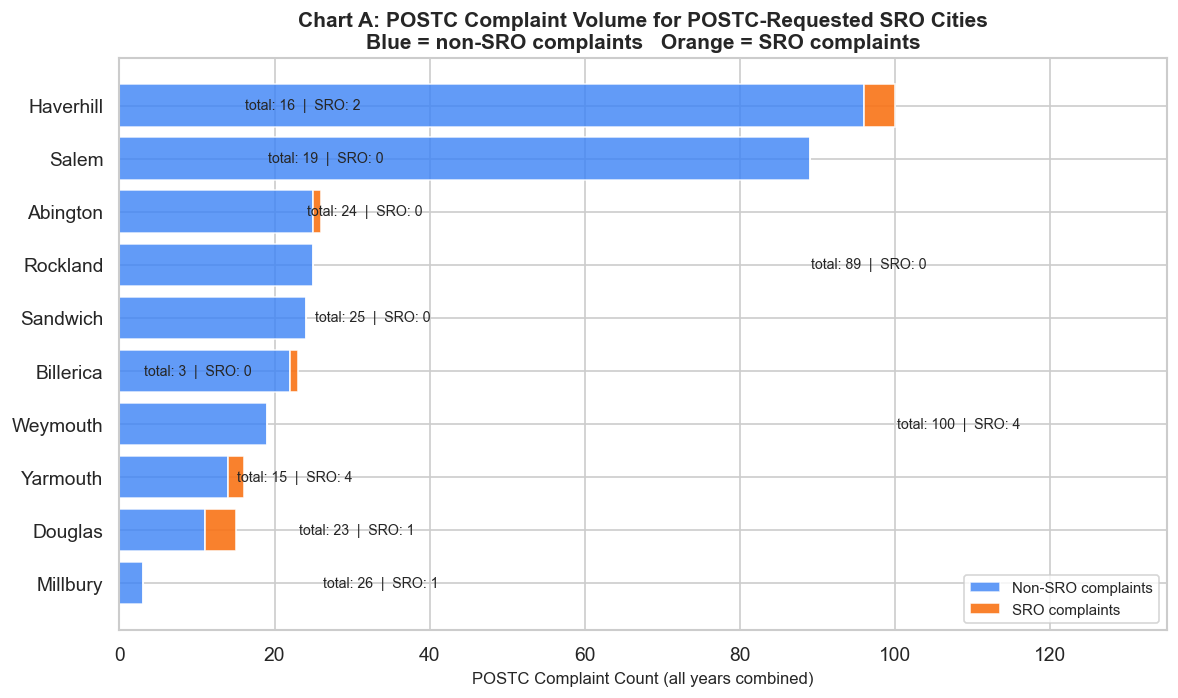

State averages — Discipline Rate: 2.4%  |  OSS Rate: 2.1%
Note: based on 9 cities with POSTC-Requested SRO complaints (15 unique complaints total)



,City,POSTC Total,POSTC SRO,Avg Disc. Rate %,vs State Avg (2.4%),Avg OSS Rate %,vs State Avg (2.1%)
0,Weymouth,19,0,5.1,▲ +2.7pp,2.7,▲ +0.6pp
1,Haverhill,100,4,4.9,▲ +2.5pp,4.2,▲ +2.1pp
2,Rockland,25,0,4.4,▲ +2.0pp,3.8,▲ +1.8pp
3,Millbury,3,0,4.0,▲ +1.6pp,2.5,▲ +0.4pp
4,Abington,26,1,3.5,▲ +1.1pp,1.6,▼ -0.5pp
5,Salem,89,0,3.3,▲ +0.9pp,2.4,▲ +0.3pp
6,Sandwich,24,0,2.2,▼ -0.2pp,1.0,▼ -1.1pp
7,Douglas,15,4,2.0,▼ -0.4pp,1.8,▼ -0.2pp
8,Billerica,23,1,1.5,▼ -0.9pp,1.4,▼ -0.7pp


In [62]:
sro_cities = dank[dank['is_SRO']]['city'].unique()

# ── Chart A: POSTC complaint totals for SRO cities (all years) ───────────────
postc_sro_agg = (
    postc[postc['city'].isin(sro_cities)]
    .groupby('city')
    .agg(total=('POST', 'count'), sro=('is_SRO', 'sum'))
    .reset_index()
    .sort_values('total', ascending=True)
)
postc_sro_agg['non_sro'] = postc_sro_agg['total'] - postc_sro_agg['sro']

if len(postc_sro_agg) > 0:
    fig, ax = plt.subplots(figsize=(10, max(5, len(postc_sro_agg) * 0.6)))
    ax.barh(postc_sro_agg['city'], postc_sro_agg['non_sro'],
            color='#3b82f6', alpha=0.8, label='Non-SRO complaints')
    ax.barh(postc_sro_agg['city'], postc_sro_agg['sro'],
            left=postc_sro_agg['non_sro'],
            color='#f97316', alpha=0.9, label='SRO complaints')
    for _, row in postc_sro_agg.iterrows():
        ax.text(row['total'] + 0.2,
                postc_sro_agg[postc_sro_agg['city'] == row['city']].index[0],
                f"total: {int(row['total'])}  |  SRO: {int(row['sro'])}",
                va='center', fontsize=8.5)
    ax.set_xlabel('POSTC Complaint Count (all years combined)', fontsize=10)
    ax.set_title('Chart A: POSTC Complaint Volume for POSTC-Requested SRO Cities\n'
                 'Blue = non-SRO complaints   Orange = SRO complaints', fontweight='bold')
    ax.legend(fontsize=9, loc='lower right')
    ax.set_xlim(0, postc_sro_agg['total'].max() * 1.35)
    plt.tight_layout()
    plt.show()

# ── Table: DESE discipline metrics for SRO cities ─────────────────────────────
# Sample size is too small (15 unique complaints) for bar charts to be meaningful.
# A table is more honest — readers can judge the numbers directly.
dese_noncharter = dese[~dese['is_charter']]
state_avg_disc = dese_noncharter['Discipline Rate'].mean()
state_avg_oss  = dese_noncharter['% Out-of-School Suspension'].mean()

city_dese5 = (
    dese_noncharter[dese_noncharter['District Name'].isin(sro_cities)]
    .groupby('District Name')
    .agg(
        disc_rate = ('Discipline Rate', 'mean'),
        oss_rate  = ('% Out-of-School Suspension', 'mean'),
    )
    .reset_index()
    .rename(columns={'District Name': 'city'})
    .sort_values('disc_rate', ascending=False)
)

# Merge POSTC SRO counts
city_dese5 = city_dese5.merge(
    postc_sro_agg[['city', 'total', 'sro']].rename(columns={'total': 'postc_total', 'sro': 'postc_sro'}),
    on='city', how='left'
).fillna(0)

city_dese5['vs_disc_avg']  = city_dese5['disc_rate'].apply(
    lambda v: f"▲ +{v - state_avg_disc:.1f}pp" if v > state_avg_disc else f"▼ {v - state_avg_disc:.1f}pp")
city_dese5['vs_oss_avg'] = city_dese5['oss_rate'].apply(
    lambda v: f"▲ +{v - state_avg_oss:.1f}pp" if v > state_avg_oss else f"▼ {v - state_avg_oss:.1f}pp")

table = city_dese5[['city','postc_total','postc_sro','disc_rate','vs_disc_avg','oss_rate','vs_oss_avg']].rename(columns={
    'city':          'City',
    'postc_total':   'POSTC Total',
    'postc_sro':     'POSTC SRO',
    'disc_rate':     'Avg Disc. Rate %',
    'vs_disc_avg':   f'vs State Avg ({state_avg_disc:.1f}%)',
    'oss_rate':      'Avg OSS Rate %',
    'vs_oss_avg':    f'vs State Avg ({state_avg_oss:.1f}%)',
}).round({'Avg Disc. Rate %': 1, 'Avg OSS Rate %': 1}).reset_index(drop=True)

print(f'State averages — Discipline Rate: {state_avg_disc:.1f}%  |  OSS Rate: {state_avg_oss:.1f}%')
print(f'Note: based on {len(city_dese5)} cities with POSTC-Requested SRO complaints (15 unique complaints total)\n')
display(table)

---
## Key Findings

1. **POSTC-Requested is heavily school-involved** — ~49% of rows mention school/youth keywords in free-text narratives (keyword-based heuristic, not a structured field); SRO-certified officer rows exist but one complaint may span multiple rows, so unique complaint count is lower than row count
2. **94 agencies** appear in both POSTC-Requested and POSTC, enabling direct complaint-level comparison
3. **Three-way join** links these agencies to DESE school districts via city name — allowing side-by-side comparison of officer misconduct complaints and school discipline/arrest rates

## Limitations

- **Officer-level matching** between POSTC-Requested and POSTC is not possible — their ID systems are incompatible (`P-XXXXXXXX` vs `XXXX-XXXX`). All linkage is at the **agency/city level**.
- **POSTC-Requested row vs. complaint counts differ** — a single complaint (`COMPLAINTNUMBER`) can appear across multiple rows (e.g., multiple allegations). All SRO/school counts above are row-level unless noted otherwise.
- **Timeline alignment** across datasets is not reliable: POSTC uses `INCIDENT_DATE` (calendar year), DESE uses school year (Sept–Aug), and POSTC-Requested only has `CREATEDDATE` (complaint filing date, not incident date). Year-to-year panel joins would introduce unquantifiable temporal misalignment, so all cross-dataset comparisons are done on **aggregate totals/averages** across available years.
- **Potential double-counting in combined scores** — POSTC-Requested (PRR-based) and POSTC (POST Commission database) are separate systems with no common complaint ID. The same incident may appear in both datasets, meaning the combined school-related score (blue + orange in Section 1 / Section 6) may overcount complaints where both datasets captured the same event. The extent of overlap is unknown.
- **`school_related` flag is a keyword heuristic** — applied to free-text narrative fields in both datasets using the following keywords:  
  `school`, `student`, `juvenile`, `minor`, `youth`, `teen`, `sro`, `resource officer`  
  This may over-count (false positives, e.g., "student officer") and under-count (school incidents described without trigger words). The POSTC-Requested dataset is too small (378 rows) for cross-city hotspot analysis to be statistically meaningful.

---
## 6. DESE × POSTC — School Discipline vs. Police Complaint Patterns

Direct link between **DESE district-level school discipline data** and **POSTC officer complaint data**, without POSTC-Requested as intermediary.  
Join key: city name extracted from `REPORTING_AGENCY` → DESE `District Name`.  

**Question:** Do cities with more POSTC complaints (especially SRO) show higher school discipline or arrest rates?

> **Timeline limitation:** POSTC uses `INCIDENT_DATE` (calendar year), DESE reports by school year (Sept–Aug), and POSTC-Requested only has `CREATEDDATE` (complaint filing date, not incident date). A reliable year-to-year alignment is not possible across all three datasets, so this section uses **aggregate totals and averages across all available years** rather than year-matched panels.

Cities matched (POSTC × DESE): 170
  of which also in POSTC-Requested: 6 / 21
Cities with ≥1 POSTC SRO complaint: 21
Of those, with nonzero school arrest rate: 7


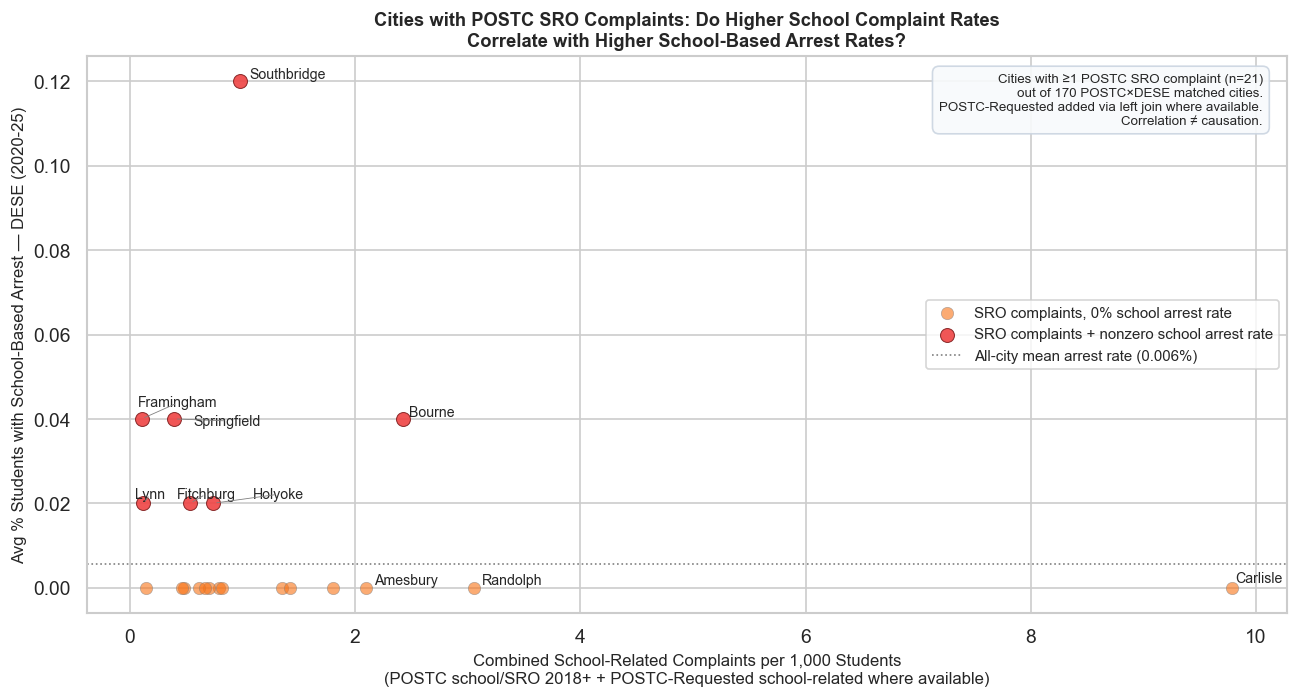

,City,POSTC-Requested School,POSTC School/SRO (2018+),Combined Score,Combined per 1k Students,Avg Disc. Rate %,Avg School Arrest %,Avg Enrollment
0,Springfield,3.0,7,10.0,0.390,5.334,0.04,25630.4
1,Randolph,2.0,7,9.0,3.057,3.897,0.00,2944.2
2,Fall River,0.0,7,7.0,0.616,5.745,0.00,11362.6
3,Carlisle,0.0,6,6.0,9.788,0.878,0.00,613.0
4,Plymouth,2.0,4,6.0,0.819,5.289,0.00,7329.6
5,Cambridge,2.0,3,5.0,0.702,1.177,0.00,7123.4
6,Amesbury,0.0,4,4.0,2.096,2.295,0.00,1908.4
7,Ashland,0.0,4,4.0,1.349,1.913,0.00,2964.2
8,Holyoke,0.0,4,4.0,0.740,8.994,0.02,5402.4
9,Haverhill,0.0,4,4.0,0.482,4.941,0.00,8299.2


Saved → ../data/sro_cities_summary.csv


In [63]:
# ── Section 6: DESE × POSTC (+POSTC-Requested where available) ────────────────
from adjustText import adjust_text

# 6a. POSTC by city (2018+)
postc_2018 = postc[postc['year'] >= 2018]
postc_city6 = postc_2018.groupby('city').agg(
    postc_total   = ('POST', 'count'),
    postc_sro     = ('is_SRO', 'sum'),
    postc_sch_sro = ('POST', lambda x: postc_2018.loc[x.index, ['is_SRO','school_related']].any(axis=1).sum()),
).reset_index()

# 6b. POSTC-Requested by city (all years — no incident date available)
dank_city6 = dank.groupby('city').agg(
    dank_school = ('school_related', 'sum'),
).reset_index()

# 6c. DESE by city (avg across all years, non-charter)
dese_city6 = dese[~dese['is_charter']].groupby('District Name').agg(
    disc_rate   = ('Discipline Rate', 'mean'),
    arrest_rate = ('% Students with a School-Based Arrest', 'mean'),
    students    = ('Students', 'mean'),
).reset_index()

# 6d. Join: POSTC × DESE (base), then left join POSTC-Requested
city6 = postc_city6.merge(dese_city6, left_on='city', right_on='District Name', how='inner').drop(columns='District Name')
city6 = city6.merge(dank_city6, on='city', how='left')
city6['dank_school'] = city6['dank_school'].fillna(0)
city6['combined_score'] = city6['postc_sch_sro'] + city6['dank_school']
city6['combined_per1k'] = city6['combined_score'] / city6['students'] * 1000
city6['postc_sro_per1k'] = city6['postc_sro'] / city6['students'] * 1000

valid6      = city6.dropna(subset=['arrest_rate']).copy()
sro_cities6 = valid6[valid6['postc_sro'] > 0].copy()

print(f'Cities matched (POSTC × DESE): {len(valid6)}')
print(f'  of which also in POSTC-Requested: {(sro_cities6["dank_school"] > 0).sum()} / {len(sro_cities6)}')
print(f'Cities with ≥1 POSTC SRO complaint: {len(sro_cities6)}')
print(f'Of those, with nonzero school arrest rate: {(sro_cities6["arrest_rate"] > 0).sum()}')

# ── Chart ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))

has_arrest = sro_cities6['arrest_rate'] > 0

ax.scatter(sro_cities6.loc[~has_arrest, 'combined_per1k'],
           sro_cities6.loc[~has_arrest, 'arrest_rate'],
           alpha=0.6, color='#f97316', edgecolors='gray', linewidths=0.4, s=55,
           label='SRO complaints, 0% school arrest rate')
ax.scatter(sro_cities6.loc[has_arrest, 'combined_per1k'],
           sro_cities6.loc[has_arrest, 'arrest_rate'],
           alpha=0.9, color='#ef4444', edgecolors='#7f1d1d', linewidths=0.6, s=70,
           label='SRO complaints + nonzero school arrest rate')

texts = []
for _, r in sro_cities6[has_arrest].iterrows():
    texts.append(ax.text(r['combined_per1k'], r['arrest_rate'], r['city'], fontsize=8.5))
for _, r in sro_cities6[~has_arrest].nlargest(3, 'combined_per1k').iterrows():
    texts.append(ax.text(r['combined_per1k'], r['arrest_rate'], r['city'], fontsize=8.5))

adjust_text(texts, ax=ax,
            arrowprops=dict(arrowstyle='-', color='gray', lw=0.5),
            expand_points=(1.4, 1.6), force_points=(0.3, 0.4))

ax.axhline(valid6['arrest_rate'].mean(), color='gray', linestyle=':', linewidth=1,
           label=f"All-city mean arrest rate ({valid6['arrest_rate'].mean():.3f}%)")

ax.set_xlabel('Combined School-Related Complaints per 1,000 Students\n'
              '(POSTC school/SRO 2018+ + POSTC-Requested school-related where available)', fontsize=10)
ax.set_ylabel('Avg % Students with School-Based Arrest — DESE (2020-25)', fontsize=10)
ax.set_title('Cities with POSTC SRO Complaints: Do Higher School Complaint Rates\nCorrelate with Higher School-Based Arrest Rates?',
             fontweight='bold', fontsize=11)
ax.legend(fontsize=9)
ax.text(0.98, 0.97,
        f"Cities with ≥1 POSTC SRO complaint (n={len(sro_cities6)})\n"
        f"out of {len(valid6)} POSTC×DESE matched cities.\n"
        f"POSTC-Requested added via left join where available.\n"
        f"Correlation ≠ causation.",
        transform=ax.transAxes, fontsize=8, va='top', ha='right',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#f8fafc', edgecolor='#cbd5e1', alpha=0.9))

plt.tight_layout()
plt.show()

# ── Summary table ──────────────────────────────────────────────────────────────
summary_table = sro_cities6.sort_values('combined_score', ascending=False)[
    ['city','dank_school','postc_sch_sro','combined_score','combined_per1k','disc_rate','arrest_rate','students']
].rename(columns={
    'city':           'City',
    'dank_school':    'POSTC-Requested School',
    'postc_sch_sro':  'POSTC School/SRO (2018+)',
    'combined_score': 'Combined Score',
    'combined_per1k': 'Combined per 1k Students',
    'disc_rate':      'Avg Disc. Rate %',
    'arrest_rate':    'Avg School Arrest %',
    'students':       'Avg Enrollment'
}).round(3).reset_index(drop=True)

display(summary_table)

csv_path = '../data/sro_cities_summary.csv'
summary_table.to_csv(csv_path, index=False)
print(f'Saved → {csv_path}')